# Indexing 3: refine and build the adaptive basis (10 degree mosaicity)

1. Refine the pbp map: every peak is assigned a position along the beam
   (its diffraction origin), and the candidate grains of every voxel are
   refined against the peaks passing through it.
2. Segment the refined map into grains (flood fill on the best orientation) and sort the
   candidates of every voxel by completeness (unique peaks relative to the
   best voxel of the same grain).
3. Build the adaptive basis: all candidate orientations of all voxels, thinned so that
   no two orientations are closer than `theta_deg`. This is the orientation grid
   used in the texture tomography.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os

import numpy as np
import matplotlib.pyplot as plt
import ImageD11.unitcell
import ImageD11.sinograms.point_by_point as pbp
from scipy.spatial.transform import Rotation as R
from diffractom import Grid
from simtools import dummy, io, orientations, paths, pbp_maps, plot

plot.dark()

In [2]:
SAMPLE = "domains_mosaicity_10p0deg"
savefile = os.path.join(paths.process_dir(SAMPLE), "peaks_2d")

colf = io.read_peaks(paths.peaks_path(SAMPLE))
ypositions, ystep, ymin, y0 = dummy.add_pbp_columns(colf)
dset = dummy.load_dset(savefile + "_dummy_dset.pkl")
dset.y0 = y0
pbpmap = pbp.PBPMap(savefile + "_pbpmap.h5")

Reading your columnfile in hdf format


In [3]:
pars = colf.parameters.parameters
ucell = ImageD11.unitcell.unitcell(
    [pars["cell__a"], pars["cell__b"], pars["cell__c"], pars["cell_alpha"], pars["cell_beta"], pars["cell_gamma"]],
    pars["cell_lattice_[P,A,B,C,I,F,R]"],
)
ucell.makerings(colf.ds.max())

In [4]:
multi_channel = pbp_maps.MultiChannelMap(pbpmap, ucell)
print(f"{multi_channel.nchannels} candidate grains (channels) per voxel at most")

39 candidate grains (channels) per voxel at most


## Refinement

In [5]:
dset.refmapfile = savefile + "_pbpmap.h5"  # pbp map input
dset.refpeaksfile = savefile + "_icolfile_refine.h5"  # peaks with diffraction origins
dset.refoutfile = savefile + "_pbpmap_refine.h5"  # refined pbp map
dset.refmanfile = savefile + "_pbprefiner.h5"  # the refiner itself

eta_wedge = 6
etacut = np.abs(np.sin(np.radians(eta_wedge)))
ifrac = colf.sum_intensity.min() / colf.sum_intensity.max()  # use all peaks

refiner = pbp.PBPRefine(
    dset,
    phase_name=None,
    hkl_tol_origins=0.15,
    hkl_tol_refine=0.08,
    hkl_tol_refine_merged=0.08,
    ds_tol=0.012,
    etacut=etacut,
    ifrac=ifrac,
    forref=None,
    y0=y0,
    min_grain_npks=10,
)
refiner.setmap(pbpmap)
refiner.setpeaks(colf, del_existing=True, prompt_del=False)

0 0.4277 (1, 1, 1) 8 42927 used, sum_intensity> 1.0
1 0.4939 (0, 2, 0) 6 28894 used, sum_intensity> 0.6869197903869599
2 0.6985 (2, 2, 0) 12 64294 used, sum_intensity> 0.37815890816395026
3 0.8191 (1, 3, 1) 24 131078 used, sum_intensity> 0.25082382545359183
4 0.8555 (2, 2, 2) 8 47284 used, sum_intensity> 0.2219996909191098


5 0.9878 (0, 0, 4) 6 31677 used, sum_intensity> 0.12821081189930209
6 1.0765 (1, 3, 3) 24 144270 used, sum_intensity> 0.09587751655065727
7 1.1044 (2, 0, 4) 24 139951 used, sum_intensity> 0.11387133181082376
8 1.2098 (2, 4, 2) 24 152280 used, sum_intensity> 0.05509601020279141
9 1.2832 (3, 3, 3) 32 197104 used, sum_intensity> 0.053244646890693074


10 1.3970 (4, 0, 4) 12 80435 used, sum_intensity> 0.023560393313237872
11 1.4610 (1, 5, 3) 48 326214 used, sum_intensity> 0.023647810130672534
12 1.4817 (4, 4, 2) 30 206818 used, sum_intensity> 0.016727832421960978
13 1.5619 (6, 2, 0) 24 166605 used, sum_intensity> 0.011053544361693327
14 1.6194 (3, 3, 5) 24 172581 used, sum_intensity> 0.010532165486279462


15 1.6381 (2, 6, 2) 24 173239 used, sum_intensity> 0.007842537335566625
16 1.7110 (4, 4, 4) 8 60626 used, sum_intensity> 0.004923440039087805
17 1.7636 (5, 5, 1) 48 350350 used, sum_intensity> 0.005315254702946727
18 1.7808 (6, 0, 4) 24 176783 used, sum_intensity> 0.004981197579178563
19 1.8481 (2, 6, 4) 48 348961 used, sum_intensity> 0.0038479009817220804


20 1.8969 (7, 3, 1) 72 479399 used, sum_intensity> 0.0027348975740272147
21 1.9757 (0, 0, 8) 6 36509 used, sum_intensity> 0.0011660779039944804
22 2.0214 (7, 3, 3) 24 155495 used, sum_intensity> 0.0013971080643575098
23 2.0365 (0, 2, 8) 48 280976 used, sum_intensity> 0.0016328212685116819
24 2.0955 (2, 8, 2) 36 179820 used, sum_intensity> 0.0012363235608616177


25 2.1387 (5, 5, 5) 56 264205 used, sum_intensity> 0.0008382648386145059
26 2.1529 (6, 2, 6) 24 127122 used, sum_intensity> 0.0009537799187960207
27 2.2088 (4, 8, 0) 24 58061 used, sum_intensity> 0.0004089858244264442
28 2.2499 (1, 9, 1) 72 147393 used, sum_intensity> 0.0003824485762766368
29 2.2634 (8, 2, 4) 48 98802 used, sum_intensity> 0.00027786059827445445


30 2.3167 (4, 6, 6) 24 21091 used, sum_intensity> 0.00016702856188408218
31 2.3558 (9, 1, 3) 48 38052 used, sum_intensity> 0.00014985740131655972
32 2.4197 (4, 8, 4) 24 9043 used, sum_intensity> 8.897783203170732e-05
33 2.4572 (3, 3, 9) 72 20113 used, sum_intensity> 6.712362767304237e-05
34 2.4696 (8, 6, 0) 30 13635 used, sum_intensity> 6.400159847894738e-05


35 2.5185 (2, 6, 8) 72 7212 used, sum_intensity> 4.9952467105519905e-05
36 2.5545 (2, 10, 2) 104 4540 used, sum_intensity> 2.9659277343902444e-05
37 2.6483 (6, 8, 4) 120 208 used, sum_intensity> 9.366087582284983e-06
38 2.7053 (4, 2, 10) 48 11 used, sum_intensity> 9.366087582284983e-06


Using for refinement: 4871453 npks, forref 1410 range(0, 39)


The sample mask: voxels whose reconstructed peak intensity is above `manual_threshold`.

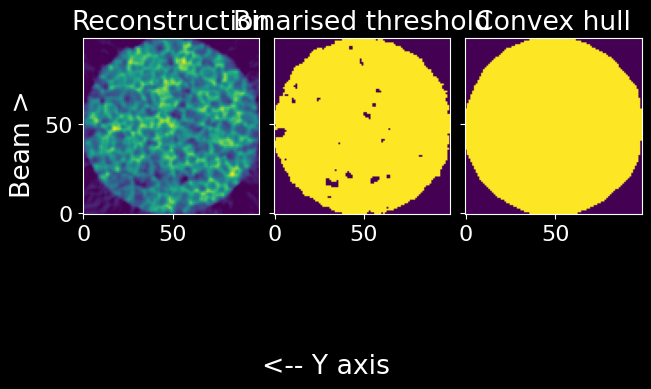

In [6]:
refiner.setmask(manual_threshold=0.65, doplot=True, use_icolf=True)

Diffraction origins are computed from the best candidate of every voxel.

Getting gvecs...
Lexsort...
Running numba computation on 31 threads, may take a while!


xpos_refined column added to self.icolf
Saving self.icolf to disk with new column


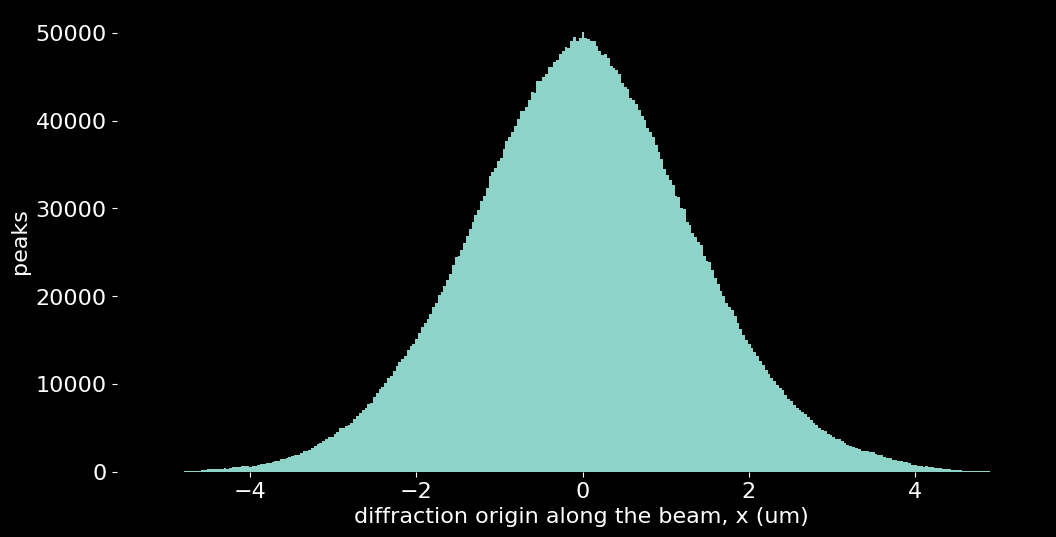

In [7]:
refiner.singlemap = multi_channel.ubi[:, :, 0]
refiner.get_origins(guess_speed=False, save_peaks_after=True)

xpos = refiner.icolf.xpos_refined[refiner.icolf.isel] if hasattr(refiner.icolf, "isel") else refiner.icolf.xpos_refined
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.hist(xpos, bins=300)
ax.set_xlabel("diffraction origin along the beam, x (um)")
ax.set_ylabel("peaks")
plot.despine(ax)
plt.show()

In [8]:
output_filename = savefile + "_refined_pbpmap.h5"
if os.path.isfile(output_filename):
    os.remove(output_filename)
refiner.run_refine(points_step_space=None, npoints=None, output_filename=output_filename, use_cluster=False, pythonpath=None)

Launching Numba parallel refinement on 31 threads


Saving refined map to disk


Reading your columnfile in hdf format


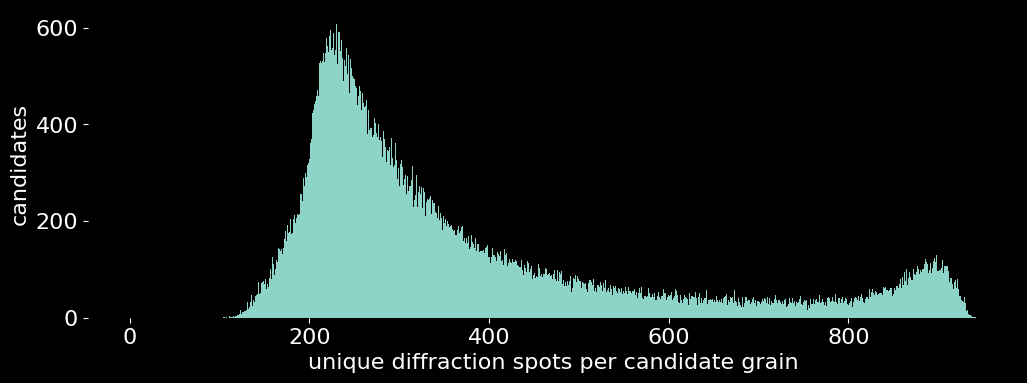

In [9]:
refined_pbpmap = pbp.PBPMap(refiner.refinedmap_filename)
refined = pbp_maps.MultiChannelMap(refined_pbpmap, ucell)

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(refined_pbpmap.nuniq, bins=np.arange(0.5, np.max(refined_pbpmap.nuniq) + 0.51, 1))
ax.set_xlabel("unique diffraction spots per candidate grain")
ax.set_ylabel("candidates")
plot.despine(ax)
plt.show()

## Grain segmentation and completeness

In [10]:
segmap = pbp_maps.segment_grains(
    refined,
    refiner.mask,
    local_disorientation_tolerance=5,  # deg, between neighbouring voxels
    max_grains=999,
    min_grain_size=5,  # voxels
    seed=0,
)
refined.normalize_per_grain(segmap)
refined.sort()  # by completeness, then total peaks
print(f"{int(np.nanmax(segmap))} grains")

50 grains


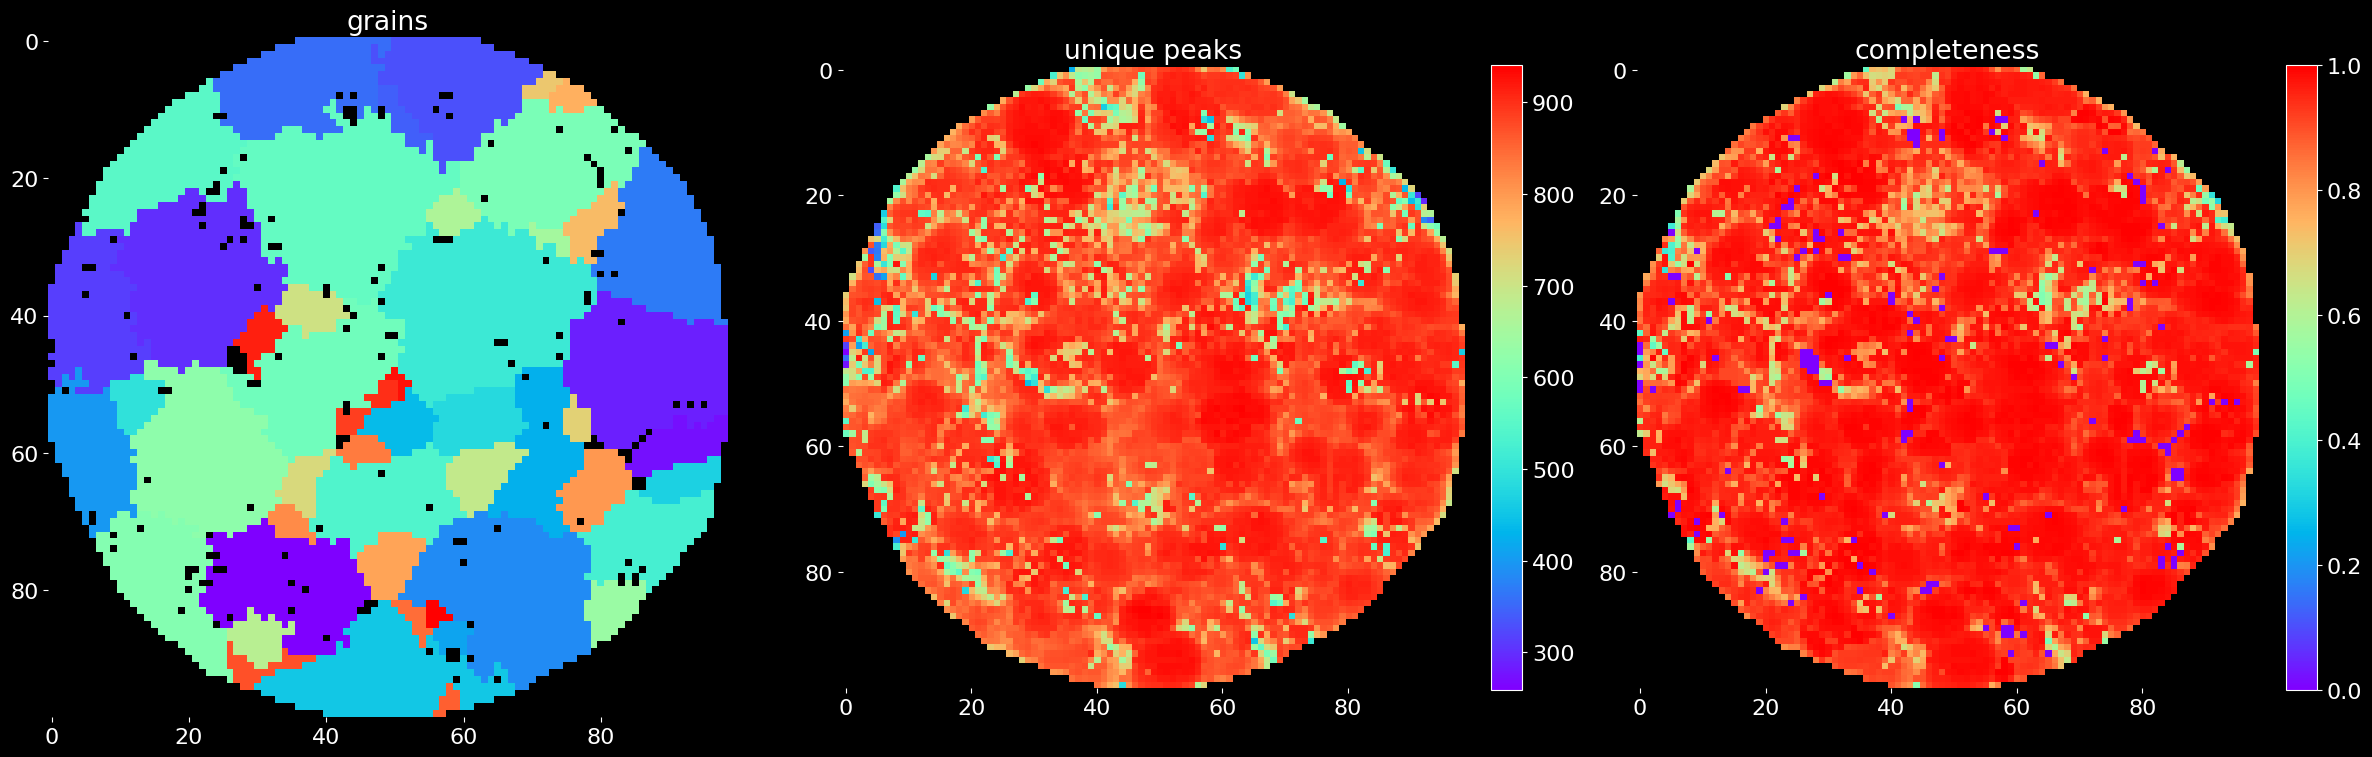

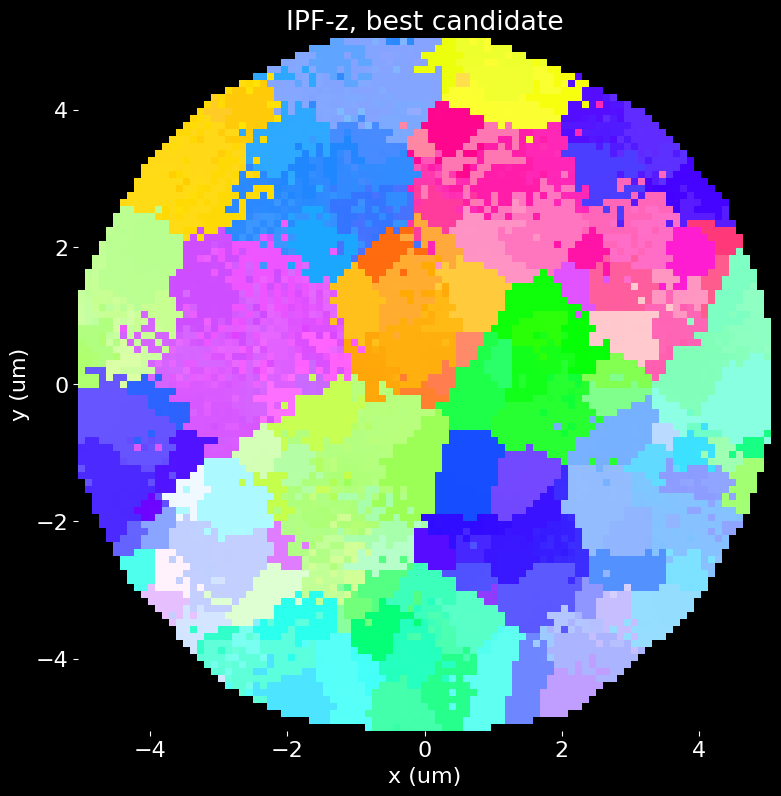

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(24, 8))
ax[0].imshow(segmap, cmap="rainbow")
ax[0].set_title("grains")
for a, (field, title) in zip(ax[1:], [(refined.nuniq[:, :, 0], "unique peaks"), (refined.completeness[:, :, 0], "completeness")]):
    _s = field.copy()
    _s[~refiner.mask] = np.nan
    im = a.imshow(_s, cmap="rainbow")
    a.set_title(title)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
plot.despine(ax)
plt.tight_layout()
plt.show()

_s = refined.rgb[:, :, 0, 2].copy()
_s[~refiner.mask] = np.nan
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
ax.pcolormesh(dset.sx_grid, dset.sy_grid, _s)
ax.set_aspect("equal")
ax.set_title("IPF-z, best candidate")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
plot.despine(ax)
plt.show()

## Build the adaptive basis

All candidate orientations of all voxels, in the order of the sorted map, are
thinned greedily: an orientation is kept unless it is within `theta_deg` of one
already kept (`diffractom.Grid.prune_close_orientations`).

In [12]:
theta_deg = 0.4

u = refined.u.reshape(-1, 3, 3)
u = u[np.any(u != 0, axis=(1, 2))]  # drop empty channels
print(f"{len(u)} candidate orientations")

grid = Grid.from_rotation_matrices(u, sigma=np.deg2rad(theta_deg))  # sigma is not used for pruning
grid.prune_close_orientations(theta_deg=theta_deg)
basis = R.concatenate(grid.rotations_at_level(0)).as_matrix()
print(f"adaptive basis: {len(basis)} orientations")

os.makedirs(os.path.dirname(paths.basis_path(SAMPLE)), exist_ok=True)
np.save(paths.basis_path(SAMPLE), basis)
print("saved", paths.basis_path(SAMPLE))

124229 candidate orientations


adaptive basis: 3025 orientations
saved /dtu-compute/msaca/adaptive_basis_simulations/adaptive_basis/domains_mosaicity_10p0deg/basis.npy


## Comparison with the ground truth
The misorientation from each ground-truth mesh element to the closest basis orientation.

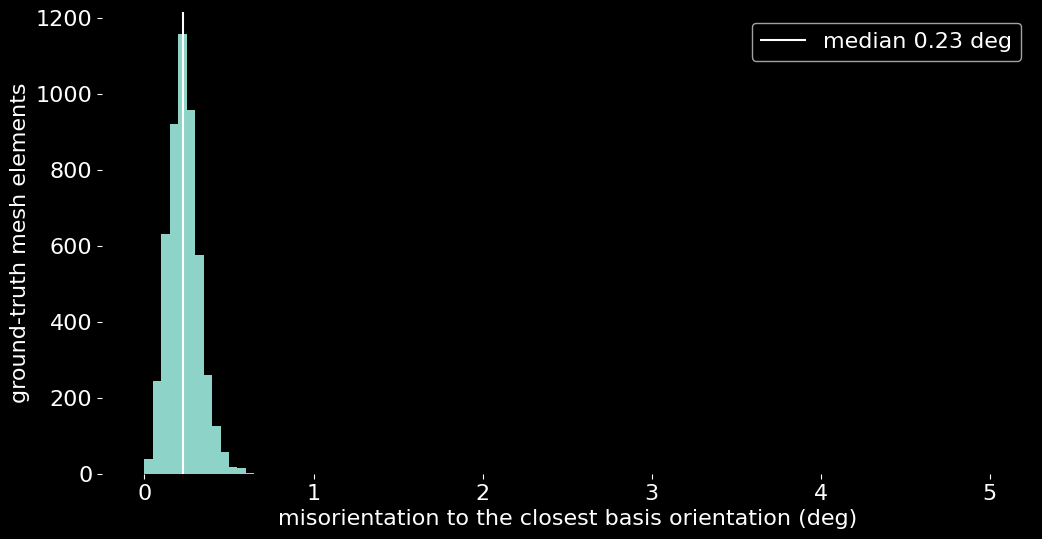

In [13]:
gt = io.read_ground_truth(SAMPLE)
idx = np.random.default_rng(0).choice(len(gt["orientation"]), 5000, replace=False)
mis = orientations.min_misorientation_deg(gt["orientation"][idx], basis)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.hist(mis, bins=100, range=(0, max(5, np.percentile(mis, 99))))
ax.axvline(np.median(mis), c="w", label=f"median {np.median(mis):.2f} deg")
ax.set_xlabel("misorientation to the closest basis orientation (deg)")
ax.set_ylabel("ground-truth mesh elements")
ax.legend()
plot.despine(ax)
plt.show()